In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

In [57]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [58]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
)
bal.columns = bal.columns.get_level_values(-1).astype(int)

mp = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
)

In [59]:
price_carriers = [
    'AC',
    'H2',
    # 'NH3',
    # 'co2 sequestered',
    # 'co2 stored',
    # 'coal',
    'gas',
    # 'gas for industry',
    # 'heat<100 industry',
    # 'heat100-200 industry',
    'heat200-500 industry',
    # 'heat>500 industry',
    # 'home battery',
    # 'low voltage',
    'methanol',
    # 'shipping methanol',
    # 'process emissions',
    'solid biomass',
    # 'solid biomass for industry',
    'rural heat',
    # 'urban decentral heat',
    # 'urban central heat',
]

In [60]:
price_carriers

['AC',
 'H2',
 'gas',
 'heat200-500 industry',
 'methanol',
 'solid biomass',
 'rural heat']

In [61]:
mp.columns = mp.columns.get_level_values(-1).astype(int)
# mp = mp.loc['gas']

In [62]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

In [63]:
gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(3000)

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [64]:
skippers = [
    'gas for industry CC',
    'heat100-200 industry gas CC',
    'heat200-500 industry gas CC',
    'heat>500 industry gas CC',
    'urban central gas CHP CC',
]

In [65]:
mp

wiggle,1500,2000,2500,3000,3500,4000
carrier,,,,,,
AC,1548.099175,141.258343,114.646835,70.659332,59.750789,59.751000
EV battery,1717.243077,162.873829,133.653328,85.187338,73.133595,73.133636
H2,1393.148183,143.852562,117.776391,68.892858,57.052223,57.066573
NH3,1523.413352,189.325524,160.723793,101.547458,87.137206,87.140402
agriculture machinery oil,75.470900,75.471449,75.471449,75.470900,75.473289,75.471251
battery,1126.666229,102.534865,83.448565,52.096649,44.146205,44.147666
biogas,1202.454411,74.974016,53.820442,20.588864,12.670053,12.669558
co2,-66.989240,-66.990496,-66.990496,-66.989241,-66.990294,-66.990778
co2 sequestered,10.771248,-24.100543,-28.426837,-29.367506,-30.045498,-30.139698


In [17]:
import pypsa

template = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_{}{}.nc'

regular_cost = list()
hike_cost = list()

for wiggle in mp.columns:

    try:
        n = pypsa.Network(Path.cwd().parent /  'results' / 'networks' / template.format(wiggle, ''))
        regular_cost.append(n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum() / 1e9)
    except FileNotFoundError:
        regular_cost.append(np.nan)

    try:
        n = pypsa.Network(Path.cwd().parent /  'results' / 'networks' / template.format(wiggle, '_50'))
        hike_cost.append(n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum() / 1e9)
    except FileNotFoundError:
        hike_cost.append(np.nan)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_1500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_1500_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2000_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2500_50.nc has buses, carriers, generators, global_constrain

In [18]:
system_costs = pd.DataFrame({
    'regular': regular_cost,
    'hike': hike_cost,
}, index=mp.columns)
print(system_costs    )

            regular         hike
wiggle                          
1500    1167.770877  1243.127341
2000    1041.589633  1141.948942
2500    1013.998625  1139.337813
3000     999.116798          NaN
3500     999.792291  1153.815261
4000     998.708436  1152.719417


In [19]:
system_costs.to_csv('regular_and_hike_system_costs.csv')

In [66]:
system_costs = pd.read_csv('regular_and_hike_system_costs.csv', index_col=0)
system_costs.dropna(inplace=True)
system_costs.index = system_costs.index.astype(int)

In [67]:
gascon.index

Index(['heat100-200 industry gas CC', 'heat100-200 industry gas',
       'gas for industry CC', 'heat200-500 industry gas CC',
       'heat>500 industry gas CC', 'urban central gas CHP CC',
       'Open-Cycle Gas', 'SMR', 'Combined-Cycle Gas',
       'heat200-500 industry gas', 'urban central gas boiler', 'SMR CC',
       'heat>500 industry gas', 'rural gas boiler',
       'urban decentral gas boiler', 'gas for industry',
       'urban central gas CHP'],
      dtype='object', name='carrier')

/tmp/ipykernel_206425/1770486993.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_price.set_yticklabels(yticklabels)
/tmp/ipykernel_206425/1770486993.py:325: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


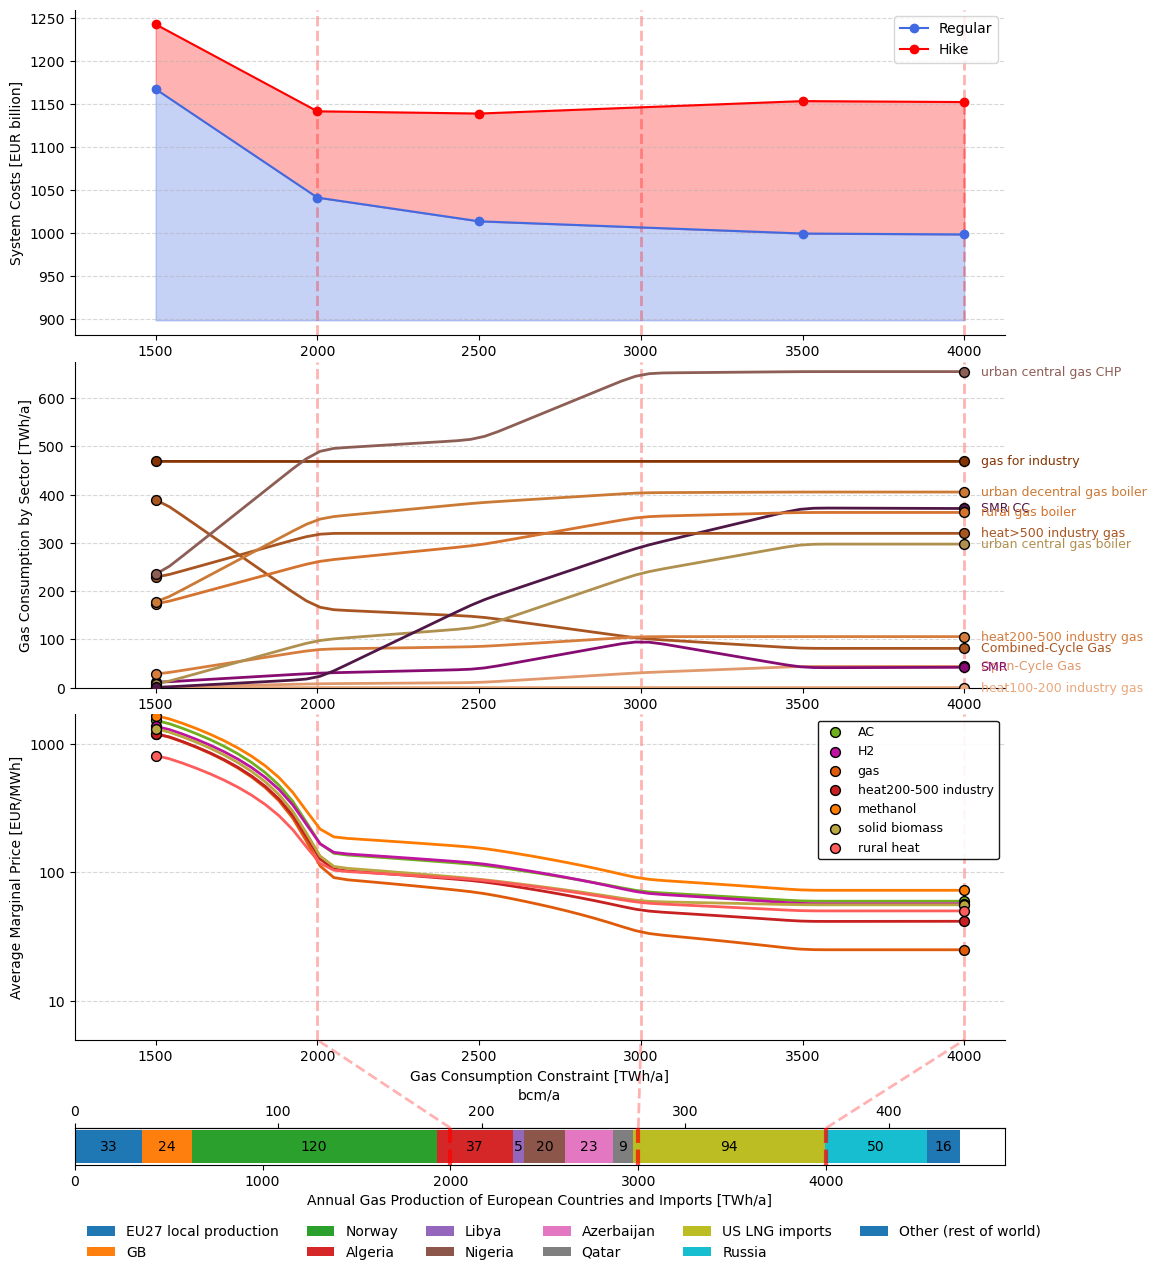

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Load tech colors from config
import yaml
with open('../config/plotting.default.yaml', 'r') as f:
    config = yaml.safe_load(f)
tech_colors = config['plotting']['tech_colors']

fig = plt.figure(figsize=(12, 15))
gs = fig.add_gridspec(4, 1, height_ratios=[2, 2, 2, 0.6], hspace=0.1)
ax_sc = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])
ax_price = fig.add_subplot(gs[2])
gs.update(hspace=0.1)
gs2 = fig.add_gridspec(4, 1, height_ratios=[2, 2, 2, 0.6], hspace=2.5)
ax2 = fig.add_subplot(gs2[3])

ax_sc.plot(
    system_costs.index,
    system_costs['regular'],
    color='royalblue',
    marker='o',
    label='Regular',
)
ax_sc.fill_between(
    system_costs.index,
    system_costs['regular'].min() * 0.9,
    system_costs['regular'],
    color='royalblue',
    alpha=0.3,
)
ax_sc.plot(
    system_costs.index,
    system_costs['hike'],
    color='red',
    marker='o',
    label='Hike',
)
ax_sc.fill_between(
    system_costs.index,
    system_costs['regular'],
    system_costs['hike'],
    color='red',
    alpha=0.3,
)

ax_sc.set_ylabel('System Costs [EUR billion]')
ax_sc.grid(linestyle='--', alpha=0.5, axis='y')
ax_sc.legend(loc='upper right')

# Get the max y-value for the background
y_max = gascon.max().max() + 20

# Track lines for legend
lines_for_legend = []
labels_for_legend = []

for carrier in gascon.index:
    if carrier in skippers:
        continue

    # Original data points
    x = gascon.columns.values
    y = gascon.loc[carrier].values

    # Create interpolated points for smoother curve
    from scipy.interpolate import interp1d
    x_interp = np.linspace(x.min(), x.max(), len(x) * 10)
    f = interp1d(x, y, kind='linear')
    y_interp = f(x_interp)

    # Apply Gaussian smoothing (exponential-based, highly localized)
    # sigma controls the smoothing width - smaller values = more localized
    y_smooth = gaussian_filter1d(y_interp, sigma=0.8)

    # Get color from tech_colors dict, fallback to gray if not found
    color = tech_colors.get(carrier, '#808080')

    line = ax.plot(
        x_interp,
        y_smooth,
        linewidth=2,
        color=color,
        label=carrier
    )

    # Add scatter points at the beginning and end of each line
    ax.scatter(
        [x_interp[0], x_interp[-1]],
        [y_smooth[0], y_smooth[-1]],
        color=color,
        s=50,
        zorder=5,
        edgecolors='k',
        linewidths=1
    )

    # Add text label at the end of the line
    ax.text(
        x_interp[-1] + 50,
        y_smooth[-1],
        carrier,
        fontsize=9,
        verticalalignment='center',
        color=color
    )

    lines_for_legend.append(line[0])
    labels_for_legend.append(carrier)

ax.set_ylabel('Gas Consumption by Sector [TWh/a]')

ax.set_xlim(1250, 4125)
ax.set_ylim(0, y_max)

ax.grid(linestyle='--', alpha=0.5, axis='y')


# Track lines for price legend
lines_for_price_legend = []
labels_for_price_legend = []

# Get symmetric y-axis limits
y_max_price = mp.loc[mp.index.intersection(price_carriers)].abs().max().max()
y_min_price = mp.loc[mp.index.intersection(price_carriers)].min().min()

for carrier in price_carriers:
    if carrier not in mp.index:
        continue
    
    # Original data points
    x = mp.columns.values
    y = mp.loc[carrier].values
    
    # Create interpolated points for smoother curve
    from scipy.interpolate import interp1d
    x_interp = np.linspace(x.min(), x.max(), len(x) * 10)
    f = interp1d(x, y, kind='linear')
    y_interp = f(x_interp)
    
    # Apply Gaussian smoothing
    y_smooth = gaussian_filter1d(y_interp, sigma=0.8)
    
    # Get color from tech_colors dict, fallback to gray if not found
    color = tech_colors.get(carrier, '#808080')
    
    line = ax_price.plot(
        x_interp,
        y_smooth,
        linewidth=2,
        color=color,
        label=carrier
    )

    # Add scatter points at the beginning and end of each line
    scatter = ax_price.scatter(
        [x_interp[0], x_interp[-1]],
        [y_smooth[0], y_smooth[-1]],
        color=color,
        s=50,
        zorder=5,
        edgecolors='k',
        linewidths=1
    )

    lines_for_price_legend.append(scatter)
    labels_for_price_legend.append(carrier)

ax_price.set_xlabel('Gas Consumption Constraint [TWh/a]')
ax_price.set_ylabel('Average Marginal Price [EUR/MWh]')

ax_price.set_ylim(5, y_max_price)
ax_price.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax_price.set_yscale('symlog', linthresh=1)
ax_price.grid(linestyle='--', alpha=0.5, axis='y')

# Custom y-tick labels
yticks = ax_price.get_yticks()
yticklabels = []
for tick in yticks:
    if tick == 1000:
        yticklabels.append('1000')
    elif tick == 100:
        yticklabels.append('100')
    else:
        yticklabels.append(f'{tick:.0f}')
ax_price.set_yticklabels(yticklabels)

# Add legend to the center plot (ax_price)
ax_price.legend(
    lines_for_price_legend,
    labels_for_price_legend,
    loc='upper right',
    fontsize=9,
    framealpha=0.9,
    edgecolor='black'
)

for a in [ax_sc, ax, ax_price]:
    a.set_xlim(1250, 4125)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)

TWH_PER_BCM = 10.83  # typical HHV/GCV-ish conversion used in many EU gas contexts

# Conversion used: 1 bcm ≈ 35.8 PJ = 35_800 TJ (typical LHV-based rule of thumb)
TJ_per_bcm = 35_800

gas_bcm_2025_by_origin = {
    "Romania":      359_943 / TJ_per_bcm,  # ≈ 10.05 bcm
    "Netherlands":  322_642 / TJ_per_bcm,  # ≈  9.01 bcm
    "Germany":      136_227 / TJ_per_bcm,  # ≈  3.81 bcm
}

# optional: rounded view
gas_bcm_2025_by_origin_rounded = {k: round(v, 2) for k, v in gas_bcm_2025_by_origin.items()}
gas_bcm_2025_by_origin_rounded


gas_bcm_2025_by_origin = {
    "EU27 local production": 33.0,     # ~4 * (8 bcm in Q2 2025) proxy :contentReference[oaicite:0]{index=0}
    "Norway": 120.4,                   # NOD 2025 production forecast :contentReference[oaicite:1]{index=1}
    "GB": 24.5,                        # UK annual production expectation (NSTA-based) :contentReference[oaicite:2]{index=2}

    "Azerbaijan": 23.5116072041,
    "Qatar": 9.8011006471,
    "US LNG imports": 94.5567955626,

    "Algeria": 37.5,
    "Libya": 5.6,

    "Russia": 50.0,
    "Nigeria": 20.0,
    "Other (rest of world)": 16.4987053062,
}


# gas_bcm_2025_by_origin.update({
    # "GB": 27.9837955016,
    # "Norway": 124.,
    # "northern-african imports": 43.0788492119,  # Algeria (LNG+pipeline) + Libya (pipeline)
    # "Azerbaijan": 23.5116072041,
    # "Qatar": 9.8011006471,
    # "US LNG imports": 94.5567955626,
    # "Other": 86.4987053062,                 # includes e.g. Russia, Nigeria, etc.
# })

# Plot order requested
order = [
    "EU27 local production",
    "GB",
    "Norway",
    "Algeria",
    "Libya",
    "Nigeria",
    "Azerbaijan",
    "Qatar",
    "US LNG imports",
    "Russia",
    "Other (rest of world)",
]

# Convert to TWh for bottom axis (plotting axis)
vals_bcm = [gas_bcm_2025_by_origin[k] for k in order]
vals_twh = [v * TWH_PER_BCM for v in vals_bcm]

# Create stacked bar plot in third subplot
left = 0
for i, (label, twh, bcm) in enumerate(zip(order, vals_twh, vals_bcm)):
    ax2.barh(0, twh, left=left, label=label)
    # Add text label in the middle of each segment
    if twh > 0:
        ax2.text(left + twh/2, 0, f"{int(bcm)}", va="center", ha="center")
    left += twh

ax2.set_yticks([])
ax2.set_xlabel("Annual Gas Production of European Countries and Imports [TWh/a]")
ax2.legend(loc='upper left', bbox_to_anchor=(-0., -1.3), ncol=len(order)//2 + 1, frameon=False)

# Secondary (top) axis in bcm
secax = ax2.secondary_xaxis(
    "top",
    functions=(lambda twh: twh / TWH_PER_BCM, lambda bcm: bcm * TWH_PER_BCM),
)
secax.set_xlabel("bcm/a")

# Add vertical lines at important values on ax2
for x_val in [2000, 3000, 4000]:
    ax2.axvline(x_val, color='r', linestyle='--', linewidth=3, alpha=0.7, zorder=10)

# Add continuous vertical lines across the upper three axes with lower alpha
for x_val in [2000, 3000, 4000]:
    # Draw lines with lower alpha on the upper three axes
    for a in [ax_sc, ax, ax_price]:
        a.axvline(x_val, color='r', linestyle='--', linewidth=2, alpha=0.3, zorder=1)

# Add diagonal lines connecting ax2 to ax_price
for x_val in [2000, 3000, 4000]:
    # Get the figure coordinates for the connection points
    # Bottom point: top of ax2 at x_val
    # Top point: bottom of ax_price at x_val
    
    # Transform x_val to figure coordinates for ax2 (top edge)
    ax2_trans = ax2.transData.transform([(x_val, ax2.get_ylim()[1])])[0]
    ax2_fig = fig.transFigure.inverted().transform(ax2_trans)
    
    # Transform x_val to figure coordinates for ax_price (bottom edge)
    ax_price_trans = ax_price.transData.transform([(x_val, ax_price.get_ylim()[0])])[0]
    ax_price_fig = fig.transFigure.inverted().transform(ax_price_trans)
    
    # Draw line in figure coordinates
    line = plt.Line2D(
        [ax2_fig[0], ax_price_fig[0]],
        [ax2_fig[1], ax_price_fig[1]],
        transform=fig.transFigure,
        color='r',
        linestyle='--',
        linewidth=2,
        alpha=0.3,
        zorder=1
    )
    fig.add_artist(line)

plt.tight_layout()
plt.show()

In [98]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = 4000 # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

In [100]:
df

,phase_out_prices,phase_out_volume
carrier,,
heat100-200 industry gas,33.68858,1000
SMR,33.68858,1000
heat100-200 industry gas CC,69.812108,1500
heat200-500 industry gas CC,69.812108,1500
heat>500 industry gas CC,69.812108,1500
Open-Cycle Gas,69.812108,1500
urban central gas boiler,69.812108,1500
SMR CC,69.812108,1500
gas for industry CC,91.657831,2000


In [101]:
xlim_lower = df['phase_out_volume'].min()
xlim_upper = df['phase_out_volume'].max() + 100

/tmp/ipykernel_206425/3760031978.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['10', '100', '1000'])


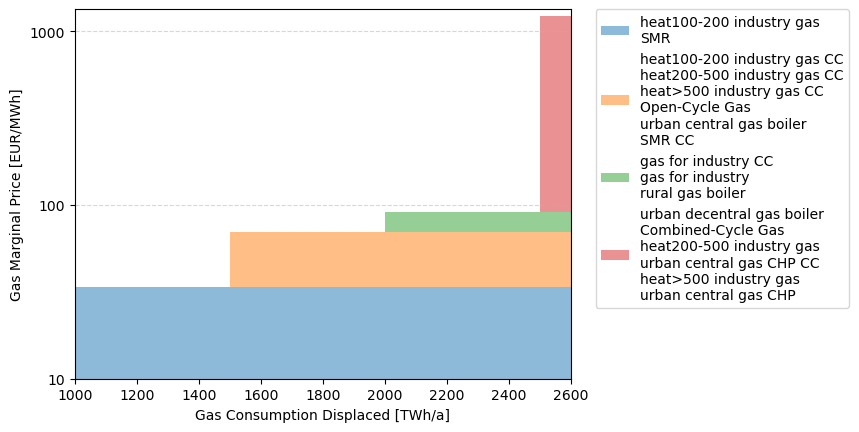

In [114]:
fig, ax = plt.subplots()

labels, handles = [], []

for i, price in enumerate(df['phase_out_prices'].unique()):

    ss = df.loc[df['phase_out_prices'] == price]


    if i == 0:
        lower = 10
    else:
        lower = upper

    upper = price
    text = '\n'.join(ss.index)

    usage = ss['phase_out_volume'].max()
    ax.fill_between([usage, xlim_upper], lower, upper, alpha=0.5, label=text)

    # ax.text(usage + 50, (lower + upper) / 2, text, ha='left', va='center', fontsize=10)

ax.set_yscale('symlog', linthresh=10)
ax.set_ylim(10, df['phase_out_prices'].max() * 1.1)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_xlim(xlim_lower, xlim_upper)
ax.grid(linestyle='--', alpha=0.5, axis='y')

ax.set_yticklabels(['10', '100', '1000'])

ax.set_xlabel('Gas Consumption Displaced [TWh/a]')
ax.set_ylabel('Gas Marginal Price [EUR/MWh]')

plt.show()

In [ ]:
mp.loc[mp.index.intersection(price_carriers)].min()

wiggle,1500,2000,2500,3000,3500,4000
carrier,,,,,,
AC,1548.099175,141.258343,114.646835,70.659332,59.750789,59.751000
H2,1393.148183,143.852562,117.776391,68.892858,57.052223,57.066573
NH3,1523.413352,189.325524,160.723793,101.547458,87.137206,87.140402
coal,9.563735,9.563358,9.563358,9.563736,9.564104,9.563893
gas,1219.137062,91.657831,69.812108,33.688580,25.081467,25.080815
gas for industry,1234.675870,107.197032,85.351310,49.227388,40.620786,40.619961
heat100-200 industry,547.358780,63.095679,53.790347,37.903463,33.935913,33.979675
heat200-500 industry,1222.337197,106.586181,85.543210,50.229217,41.615656,41.736100
heat>500 industry,1233.983552,108.286479,86.397058,50.125077,41.453940,41.502438


In [43]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator Offshore Wind (AC)            2.326909e+05        2.326909e+05   
          Offshore Wind (DC)            5.463166e+03        5.463166e+03   
          Offshore Wind (Floating)      4.966501e+03        4.966501e+03   
          Onshore Wind                  4.243680e+05        4.243680e+05   
          Run of River                  4.780433e+04        4.780433e+04   
...                                              ...                 ...   
Store     gas                           1.335726e+09        1.335726e+09   
          home battery                  2.044627e+05        2.044627e+05   
          methanol                      1.777291e+04        1.777291e+04   
          non-sequestered HVC           7.931300e+08        7.931300e+08   
          oil                           7.839527e+02        7.839527e+02   

                                          Supply    Withdrawal  \
Generator Offshore Wind (AC)        8.002804e+08  0.000000e+00   
          Offshore Wind (DC)        2.362813e+07  0.000000e+00   
          Offshore Wind (Floating)  1.702802e+07  0.000000e+00   
          Onshore Wind              7.636143e+08  0.000000e+00   
          Run of River              1.620941e+08  0.000000e+00   
...                                          ...           ...   
Store     gas                       6.393956e+08  6.393956e+08   
          home battery              3.637636e+07  3.637636e+07   
          methanol                  3.703908e+04  3.703908e+04   
          non-sequestered HVC       7.931300e+08  0.000000e+00   
          oil                       7.380781e+03  7.380781e+03   

                                    Energy Balance  Transmission  \
Generator Offshore Wind (AC)          8.002804e+08           0.0   
          Offshore Wind (DC)          2.362813e+07           0.0   
          Offshore Wind (Floating)    1.702802e+07           0.0   
          Onshore Wind                7.636143e+08           0.0   
          Run of River                1.620941e+08           0.0   
...                                            ...           ...   
Store     gas                         0.000000e+00           0.0   
          home battery                2.840000e-02           0.0   
          methanol                    0.000000e+00           0.0   
          non-sequestered HVC         7.931300e+08           0.0   
          oil                         0.000000e+00           0.0   

                                    Capacity Factor   Curtailment  \
Generator Offshore Wind (AC)               0.392608  2.033953e+08   
          Offshore Wind (DC)               0.493720  6.371144e+05   
          Offshore Wind (Floating)         0.391390  2.305834e+05   
          Onshore Wind                     0.205413  1.101425e+08   
          Run of River                     0.387076  4.428229e+05   
...                                             ...           ...   
Store     gas                              0.497344  0.000000e+00   
          home battery                     0.500471  0.000000e+00   
          methanol                         0.512383  0.000000e+00   
          non-sequestered HVC              0.500579  0.000000e+00   
          oil                              0.500001  0.000000e+00   

                                    Capital Expenditure  \
Generator Offshore Wind (AC)               4.996395e+10   
          Offshore Wind (DC)               1.331982e+09   
          Offshore Wind (Floating)         1.532927e+09   
          Onshore Wind                     5.156799e+10   
          Run of River                     1.473188e+10   
...                                                 ...   
Store     gas                              2.384429e+10   
          home battery                     5.154522e+09   
          methanol                         1.000333e+05   
          non-sequestered HVC              0.000000e+00   
          oil                      

In [44]:
import pandas as pd
from pathlib import Path

In [47]:
df = pd.read_csv(Path.cwd().parent / 'results' / 'csvs' / 'prices.csv', index_col=list(range(1)), header=list(range(5)))
df.loc['gas']

cluster  opt                 planning_horizon  tyndp_scenario  wiggle
50       3H-T-H-B-I-A-dist1  2035              NT              1500      1219.137062
                                                               2000        91.657831
                                                               2500        69.812108
                                                               3000        33.688580
                                                               3500        25.081467
                                                               4000        25.080815
Name: gas, dtype: float64

In [54]:
n = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / template.format(1500, ''))

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_1500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [55]:
cs = n.buses_t.marginal_price.columns
n.buses_t.marginal_price[cs[cs.str.contains('gas')]]

Bus,AL0 0 biogas,AL0 0 gas,AL0 0 gas for industry,AT0 0 biogas,AT0 0 gas,AT0 0 gas for industry,BA0 0 biogas,BA0 0 gas,BA0 0 gas for industry,BE0 0 biogas,...,SE1 0 gas for industry,SI0 0 biogas,SI0 0 gas,SI0 0 gas for industry,SK0 0 biogas,SK0 0 gas,SK0 0 gas for industry,XK0 0 biogas,XK0 0 gas,XK0 0 gas for industry
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,1202.391199,1218.935295,1234.784087,1202.561817,1218.93836,1234.786184,1202.787394,1218.936289,1234.783694,1201.814028,...,1234.039067,1202.800619,1218.948967,1234.796452,1201.814134,1218.192133,1234.039376,1202.399409,1218.967469,1234.815909
2024-01-01 03:00:00,1202.391199,1218.935258,1234.784049,1202.561813,1218.93836,1234.786184,1202.787392,1218.936265,1234.783670,1201.814027,...,1234.039067,1202.800617,1218.948954,1234.796439,1201.814132,1218.192133,1234.039376,1202.399409,1218.964674,1234.813114
2024-01-01 06:00:00,1202.391199,1218.935233,1234.784024,1202.561811,1218.93836,1234.786184,1202.787391,1218.936253,1234.783657,1201.814027,...,1234.039068,1202.800617,1218.948942,1234.796427,1201.814132,1218.192133,1234.039376,1202.399409,1218.962785,1234.811225
2024-01-01 09:00:00,1202.391199,1218.935207,1234.783998,1202.561806,1218.93836,1234.786184,1202.787390,1218.936244,1234.783648,1201.814027,...,1234.039068,1202.800615,1218.948931,1234.796416,1201.814130,1218.192133,1234.039376,1202.399409,1218.961390,1234.809830
2024-01-01 12:00:00,1202.391199,1218.935198,1234.783989,1202.561806,1218.93836,1234.786184,1202.787390,1218.936241,1234.783646,1201.814027,...,1234.039068,1202.800615,1218.948925,1234.796410,1201.814130,1218.192133,1234.039376,1202.399409,1218.960710,1234.809150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 09:00:00,1202.391199,1218.935782,1234.784573,1202.561791,1218.93836,1234.786184,1202.787385,1218.936640,1234.784045,1201.814027,...,1234.039067,1202.800610,1218.949047,1234.796532,1201.814123,1218.192133,1234.039376,1202.399409,1218.978003,1234.826443
2024-12-31 12:00:00,1202.391199,1218.935766,1234.784557,1202.561792,1218.93836,1234.786184,1202.787385,1218.936619,1234.784023,1201.814026,...,1234.039067,1202.800610,1218.949035,1234.796520,1201.814123,1218.192133,1234.039376,1202.399409,1218.976407,1234.824847
2024-12-31 15:00:00,1202.391199,1218.935788,1234.784580,1202.561803,1218.93836,1234.786184,1202.787388,1218.936622,1234.784026,1201.814027,...,1234.039067,1202.800614,1218.949032,1234.796517,1201.814128,1218.192133,1234.039376,1202.399409,1218.975883,1234.824323
